# Data acquisition

Exports Sentinel-2 chips in the TA sample format.

Important:
- If `OVERWRITE` is `False`, changing params will not change existing files.
- `BUFFER_METERS` changes the scene extent.
- `CHIP_SIZE` controls the exported pixel size.
- The export uses fixed `dimensions`, so every chip is exactly `CHIP_SIZE x CHIP_SIZE`.


In [28]:
from pathlib import Path
from urllib.request import urlopen
import shutil
import sys

import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable, **kwargs):
        return iterable

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from land_cover import DIRECTORIES, sample_dir, sample_name, spectral_name


In [29]:
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()


In [30]:
START_DATE = "2025-05-01"
END_DATE = "2025-08-28"
MAX_CLOUD = 20

BUFFER_METERS = 1280
CHIP_SIZE = 256

SAMPLE_LIMIT = None
SAMPLE_NAMES = []
OVERWRITE = True

RGB_P_LOW = 2
RGB_P_HIGH = 98
RGB_GAMMA = 1.15

BANDS = [
    "B1", "B2", "B3", "B4", "B5", "B6",
    "B7", "B8", "B8A", "B9", "B11", "B12",
]

OUTPUT_ROOT = DIRECTORIES["data_samples_generated"]
MANIFEST_PATH = DIRECTORIES["data_manifests"] / "gee_acquisition_manifest.csv"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)


In [31]:
def build_region(latitude, longitude, buffer_m=BUFFER_METERS):
    return ee.Geometry.Point([longitude, latitude]).buffer(buffer_m).bounds()


def mask_clouds(image):
    scl = image.select("SCL")
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(mask)


def build_image(region):
    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(region)
        .filterDate(START_DATE, END_DATE)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD))
        .map(mask_clouds)
        .select(BANDS)
        .median()
        .clip(region)
    )


def export_tif(image, output_path, region):
    params = {
        "name": output_path.stem,
        "bands": BANDS,
        "region": region,
        "dimensions": [CHIP_SIZE, CHIP_SIZE],
        "format": "GEO_TIFF",
        "filePerBand": False,
    }
    url = image.getDownloadURL(params)
    with urlopen(url) as response, output_path.open("wb") as file_obj:
        shutil.copyfileobj(response, file_obj)


def percentile_stretch(channel):
    low, high = np.percentile(channel, [RGB_P_LOW, RGB_P_HIGH])
    high = max(high, low + 1e-6)
    scaled = np.clip((channel - low) / (high - low), 0, 1)
    return np.power(scaled, 1 / RGB_GAMMA)


def load_rgb(path):
    with rio.open(path) as src:
        rgb = src.read([4, 3, 2]).astype(np.float32)
    rgb = np.moveaxis(rgb, 0, -1)
    return np.stack([percentile_stretch(rgb[..., i]) for i in range(3)], axis=-1)


In [32]:
locations = pd.read_csv(ROOT / "locations.csv")
locations["sample_name"] = locations["name"].map(sample_name)

if SAMPLE_NAMES:
    locations = locations[locations["sample_name"].isin(SAMPLE_NAMES)].copy()
elif SAMPLE_LIMIT is not None:
    locations = locations.head(SAMPLE_LIMIT).copy()

locations[["sample_name", "name", "latitude", "longitude", "terrain_focus"]]


,sample_name,name,latitude,longitude,terrain_focus
0,CairoUniv,Cairo University,30.026330,31.209090,urban/infrastructure
1,IconicTower,"Iconic Tower, New Administrative Capital",30.010918,31.701837,urban/infrastructure
2,SiwaOasis,Siwa Oasis,29.203200,25.519500,oasis/desert
3,KarnakLuxor,"Karnak, Luxor",25.718000,32.658300,nile/urban
4,PhilaeAswan,"Philae, Aswan",24.025500,32.884400,water/rocky urban edge
5,HawaraFayoum,"Hawara, Fayoum",29.274700,30.898600,agriculture/desert edge
6,Alexandria,Alexandria,31.205753,29.924526,coastal urban
7,GreatPyramidOfGiza,Great Pyramid of Giza,29.974167,31.133947,urban/desert edge
8,6thOfOctoberCity,6th of October City,29.816667,31.050000,urban/desert edge
9,NewCairo,New Cairo,30.030000,31.470000,urban/desert edge


In [33]:
records = []

for row in tqdm(locations.itertuples(index=False), total=len(locations), desc="Acquire"):
    sample_root = sample_dir(row.sample_name)
    sample_root.mkdir(parents=True, exist_ok=True)
    spectral_path = sample_root / spectral_name(row.sample_name)

    if not OVERWRITE and spectral_path.exists():
        status = "skipped"
    else:
        region = build_region(row.latitude, row.longitude)
        image = build_image(region)
        export_tif(image, spectral_path, region)
        status = "downloaded"

    records.append({
        "sample_name": row.sample_name,
        "name": row.name,
        "latitude": row.latitude,
        "longitude": row.longitude,
        "terrain_focus": row.terrain_focus,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "buffer_meters": BUFFER_METERS,
        "chip_size": CHIP_SIZE,
        "max_cloud": MAX_CLOUD,
        "bands": ",".join(BANDS),
        "spectral_path": str(spectral_path.relative_to(ROOT)),
        "status": status,
    })

manifest = pd.DataFrame(records)
manifest.to_csv(MANIFEST_PATH, index=False)
manifest


Acquire: 100%|██████████| 43/43 [07:30<00:00, 10.48s/it]


,sample_name,name,latitude,longitude,terrain_focus,start_date,end_date,buffer_meters,chip_size,max_cloud,bands,spectral_path,status
0,CairoUniv,Cairo University,30.026330,31.209090,urban/infrastructure,2025-05-01,2025-08-28,1280,256,20,"B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12",data/samples_generated/CairoUniv/CairoUniv_Spe...,downloaded
1,IconicTower,"Iconic Tower, New Administrative Capital",30.010918,31.701837,urban/infrastructure,2025-05-01,2025-08-28,1280,256,20,"B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12",data/samples_generated/IconicTower/IconicTower...,downloaded
2,SiwaOasis,Siwa Oasis,29.203200,25.519500,oasis/desert,2025-05-01,2025-08-28,1280,256,20,"B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12",data/samples_generated/SiwaOasis/SiwaOasis_Spe...,downloaded
3,KarnakLuxor,"Karnak, Luxor",25.718000,32.658300,nile/urban,2025-05-01,2025-08-28,1280,256,20,"B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12",data/samples_generated/KarnakLuxor/KarnakLuxor...,downloaded
4,PhilaeAswan,"Philae, Aswan",24.025500,32.884400,water/rocky urban edge,2025-05-01,2025-08-28,1280,256,20,"B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12",data/samples_generated/PhilaeAswan/PhilaeAswan...,downloaded
5,HawaraFayoum,"Hawara, Fayoum",29.274700,30.898600,agriculture/desert edge,2025-05-01,2025-08-28,1280,256,20,"B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12",data/samples_generated/HawaraFayoum/HawaraFayo...,downloaded
6,Alexandria,Alexandria,31.205753,29.924526,coastal urban,2025-05-01,2025-08-28,1280,256,20,"B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12",data/samples_generated/Alexandria/Alexandria_S...,downloaded
7,GreatPyramidOfGiza,Great Pyramid of Giza,29.974167,31.133947,urban/desert edge,2025-05-01,2025-08-28,1280,256,20,"B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12",data/samples_generated/GreatPyramidOfGiza/Grea...,downloaded
8,6thOfOctoberCity,6th of October City,29.816667,31.050000,urban/desert edge,2025-05-01,2025-08-28,1280,256,20,"B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12",data/samples_generated/6thOfOctoberCity/6thOfO...,downloaded
9,NewCairo,New Cairo,30.030000,31.470000,urban/desert edge,2025-05-01,2025-08-28,1280,256,20,"B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12",data/samples_generated/NewCairo/NewCairo_Spect...,downloaded


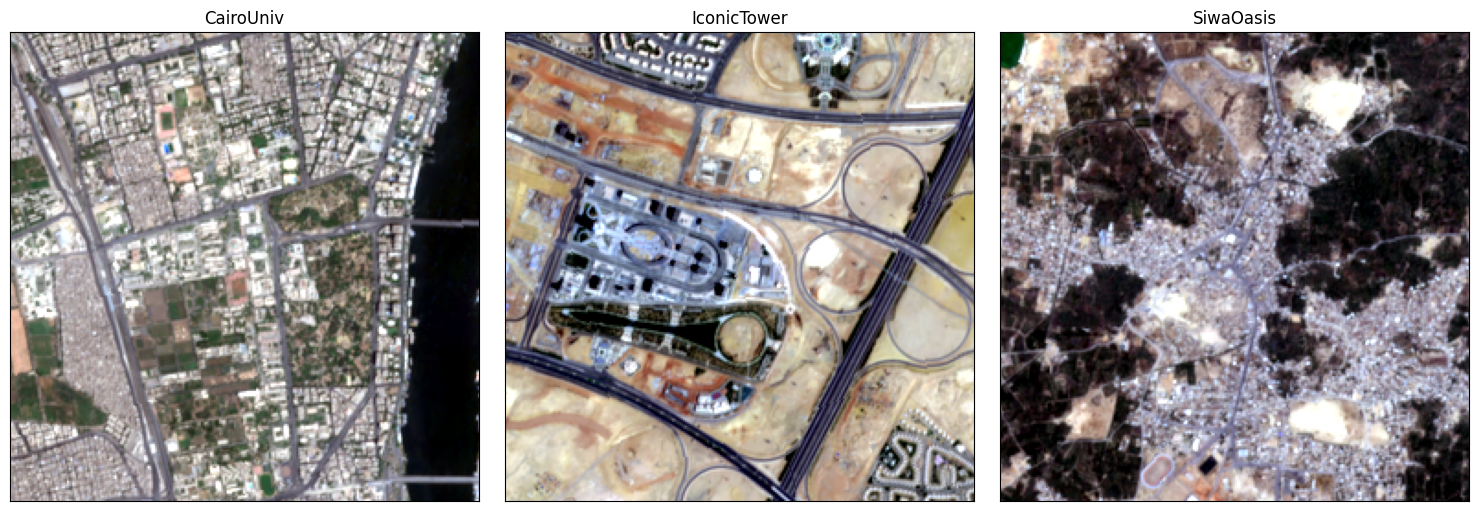

In [34]:
preview_names = SAMPLE_NAMES or locations["sample_name"].tolist()[:min(3, len(locations))]
if preview_names:
    fig, axes = plt.subplots(1, len(preview_names), figsize=(5 * len(preview_names), 5), facecolor="white")
    if len(preview_names) == 1:
        axes = [axes]
    for ax, sample in zip(axes, preview_names):
        rgb = load_rgb(sample_dir(sample) / spectral_name(sample))
        ax.imshow(rgb)
        ax.set_title(sample)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.tight_layout()
